In [145]:

import torch
from torch.utils.data import DataLoader
from dataset import LandsatDataLoader, LandsatSeqDataset
from model import TemporalPositionalNDVITransformer
from trainer.temporal_trainer import TemporalTrainer

import logging
import os
import matplotlib.pyplot as plt
import rasterio
import numpy as np
import random

# set seed for all random operations
torch.manual_seed(1)
random.seed(1)



In [146]:

def load_model(checkpoint_path: str, model, num_features: int):
    checkpoint = torch.load(checkpoint_path, map_location=torch.device("cpu"))
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model

In [147]:

def sample_data(val_loader: DataLoader, num_samples: int = 10) -> list:
    samples = []
    for i, data in enumerate(val_loader):
        if i >= num_samples:
            break
        samples.append(data)
    return samples


In [148]:

def temporal_seq_data_shaping(inputs, targets, device):
    x, year_seq = inputs.split(1, dim=-1)
    year_seq = year_seq.squeeze(-1)

    # move to device
    x = x.to(device)
    year_seq = year_seq.to(device)
    targets = targets.to(device)

    # we need to convert create season encoding from year_seq by
    # if year is full number (1980, 1981, 1982) - season is 0
    # if year is full number + 0.5 (1980.5, 1981.5, 1982.5) - season is 1
    seasons = torch.where(year_seq % 1 == 0, 0, 1)

    # convert year_seq to int
    year_seq_int = year_seq.int()
    return x, year_seq_int, seasons, targets

In [149]:
def create_outputs(model, samples: list) -> list:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    outputs_list = []

    for inputs, targets in samples:
        x, year_seq, seasons, targets = temporal_seq_data_shaping(inputs, targets, device)
        # print all the shapes in one line
        with torch.no_grad():
            # remove last dimmension of x
            x = x.squeeze(-1)
            outputs = model(x, year_seq, seasons)
            y = targets[:, 0]
            if outputs.dim() > 1 and outputs.size(1) > 1:
                outputs = outputs[:, 0]

        out_year_seq = targets[:, 1]
        outputs_list.append((x.cpu().numpy().flatten(), year_seq.cpu().numpy().flatten(), seasons.cpu().numpy().flatten(), y.cpu().numpy().flatten(), out_year_seq.cpu().numpy().flatten(), outputs.cpu().numpy().flatten()))

    return outputs_list

def evaluate_model(model, samples: list) -> None:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    criterion = torch.nn.MSELoss(reduction="mean")
    mae_criterion = torch.nn.L1Loss(reduction="mean")

    outputs_list = create_outputs(model, samples)

    for i, (x, year_seq, seasons, y, out_year_seq, outputs) in enumerate(outputs_list):
        y_tensor = torch.tensor(y, device=device)
        outputs_tensor = torch.tensor(outputs, device=device)
        
        loss = criterion(y_tensor, outputs_tensor)
        mae = mae_criterion(y_tensor, outputs_tensor)

        print(f"Sample {i+1}:")
        print(f"  True Value: {y}")
        print(f"  Predicted Value: {outputs}")
        print(f"  MSE Loss: {loss.item()}")
        print(f"  MAE: {mae.item()}")
        print()

In [150]:

experiment = "best/final/transformer_seq11"

logging.basicConfig(format="%(asctime)s - %(message)s", level=logging.INFO, datefmt="%Y-%m-%d %H:%M:%S")

logging.info("Loading validation dataset...")
batch_size = 1
split_rate = 0.1
num_workers = 8
window_size = 20
dataset = LandsatSeqDataset("../data/Landsat_NDVI_time_series_1984_to_2024.tif", window_size)
loader = LandsatDataLoader(dataset, batch_size, split_rate, split_rate, num_workers)
_, val_loader = loader.create_data_loaders()

logging.info("Creating model...")
model = TemporalPositionalNDVITransformer(embedding_dim=256, attn_heads=8, num_encoder_layers=3, sequence_length=window_size, start_year=1984, end_year=2024, max_seq_length=50, num_features=1, dropout=0.0)

logging.info("Loading model...")
checkpoint_path = os.path.join("..", "runs", experiment, "checkpoint.tar")
model = load_model(checkpoint_path, model, 1)

logging.info("Sampling data...")
samples = sample_data(val_loader, 10)

2024-12-14 22:48:39 - Loading validation dataset...
2024-12-14 22:48:39 - Original NDVI data shape: (82, 1798, 1245)
2024-12-14 22:48:39 - Year information extracted: {0: 1984, 1: 1984.5, 2: 1985, 3: 1985.5, 4: 1986, 5: 1986.5, 6: 1987, 7: 1987.5, 8: 1988, 9: 1988.5, 10: 1989, 11: 1989.5, 12: 1990, 13: 1990.5, 14: 1991, 15: 1991.5, 16: 1992, 17: 1992.5, 18: 1993, 19: 1993.5, 20: 1994, 21: 1994.5, 22: 1995, 23: 1995.5, 24: 1996, 25: 1996.5, 26: 1997, 27: 1997.5, 28: 1998, 29: 1998.5, 30: 1999, 31: 1999.5, 32: 2000, 33: 2000.5, 34: 2001, 35: 2001.5, 36: 2002, 37: 2002.5, 38: 2003, 39: 2003.5, 40: 2004, 41: 2004.5, 42: 2005, 43: 2005.5, 44: 2006, 45: 2006.5, 46: 2007, 47: 2007.5, 48: 2008, 49: 2008.5, 50: 2009, 51: 2009.5, 52: 2010, 53: 2010.5, 54: 2011, 55: 2011.5, 56: 2012, 57: 2012.5, 58: 2013, 59: 2013.5, 60: 2014, 61: 2014.5, 62: 2015, 63: 2015.5, 64: 2016, 65: 2016.5, 66: 2017, 67: 2017.5, 68: 2018, 69: 2018.5, 70: 2019, 71: 2019.5, 72: 2020, 73: 2020.5, 74: 2021, 75: 2021.5, 76: 20

In [151]:
samples[0]

[tensor([[[2.9012e-01, 1.9975e+03],
          [4.2206e-01, 1.9980e+03],
          [2.0038e-01, 1.9985e+03],
          [2.3974e-01, 1.9990e+03],
          [2.3453e-01, 1.9995e+03],
          [2.4273e-01, 2.0000e+03],
          [2.9544e-01, 2.0005e+03],
          [4.1041e-01, 2.0010e+03],
          [2.2767e-01, 2.0015e+03],
          [4.7807e-01, 2.0020e+03],
          [1.3255e-01, 2.0025e+03],
          [2.8681e-01, 2.0030e+03],
          [2.4205e-01, 2.0035e+03],
          [3.3474e-01, 2.0040e+03],
          [2.1056e-01, 2.0045e+03],
          [3.5189e-01, 2.0050e+03],
          [7.7611e-02, 2.0055e+03],
          [2.2021e-01, 2.0060e+03],
          [2.3374e-01, 2.0065e+03],
          [3.1952e-01, 2.0070e+03]]]),
 tensor([[2.3931e-01, 2.0075e+03]])]

In [152]:
logging.info("Evaluating model...")
evaluate_model(model, samples)

2024-12-14 22:48:44 - Evaluating model...


Sample 1:
  True Value: [0.2393071]
  Predicted Value: [0.27584377]
  MSE Loss: 0.0013349277433007956
  MAE: 0.03653666377067566

Sample 2:
  True Value: [0.12891057]
  Predicted Value: [0.12200552]
  MSE Loss: 4.767970312968828e-05
  MAE: 0.006905049085617065

Sample 3:
  True Value: [0.22648416]
  Predicted Value: [0.3234892]
  MSE Loss: 0.009409974329173565
  MAE: 0.09700502455234528

Sample 4:
  True Value: [0.0723023]
  Predicted Value: [0.07818846]
  MSE Loss: 3.464687688392587e-05
  MAE: 0.005886159837245941

Sample 5:
  True Value: [0.31116238]
  Predicted Value: [0.1874296]
  MSE Loss: 0.015309799462556839
  MAE: 0.12373277544975281

Sample 6:
  True Value: [0.118401]
  Predicted Value: [0.09367811]
  MSE Loss: 0.0006112212431617081
  MAE: 0.024722889065742493

Sample 7:
  True Value: [0.40669814]
  Predicted Value: [0.31084538]
  MSE Loss: 0.00918775238096714
  MAE: 0.09585276246070862

Sample 8:
  True Value: [0.3220627]
  Predicted Value: [0.31639868]
  MSE Loss: 3.20811304

In [153]:
def plot_outputs(outputs_list: list, plots_per_row: int = 2) -> None:
    num_samples = len(outputs_list)
    num_rows = (num_samples + plots_per_row - 1) // plots_per_row  # Calculate the number of rows needed

    fig, axes = plt.subplots(num_rows, plots_per_row, figsize=(15, 5 * num_rows))
    axes = axes.flatten()  # Flatten the axes array for easy iteration

    for i, (x, year_seq, seasons, y, out_year_seq, outputs) in enumerate(outputs_list):
        ax = axes[i]

        # add 0.5 to year_seq if seasons is 1
        year_seq = np.where(seasons == 1, year_seq + 0.5, year_seq)
        
        # Plot input values
        ax.plot(year_seq, x, 'g.', label='Input Values')
        ax.plot(year_seq, x, 'g-')

        # Create a new line segment to connect X to Y
        # connection_x = [year_seq[-1], out_year_seq[0]]
        # connection_y = [x[-1], y[0]]
        # ax.plot(connection_x, connection_y, 'b-', linewidth=2, label='Connection')
        
        # Plot true values and predicted values
        ax.plot(out_year_seq, y, 'b.', label='True Value')
        ax.plot(out_year_seq, y, 'b-')
        ax.plot(out_year_seq, outputs, 'r.', label='Predicted Value')
        ax.plot(out_year_seq, outputs, 'r-')
        
        ax.set_xlabel('Year')
        ax.set_ylabel('NDVI')
        ax.set_ylim(0, 1)
        ax.set_title(f'Sample {i+1}')
        ax.legend()

    plt.tight_layout()
    plt.show()


def plot_predictions(model, samples: list, plots_per_row: int = 2) -> None:
    outputs_list = create_outputs(model, samples)
    plot_outputs(outputs_list, plots_per_row)

2024-12-14 22:48:44 - Plotting predictions...


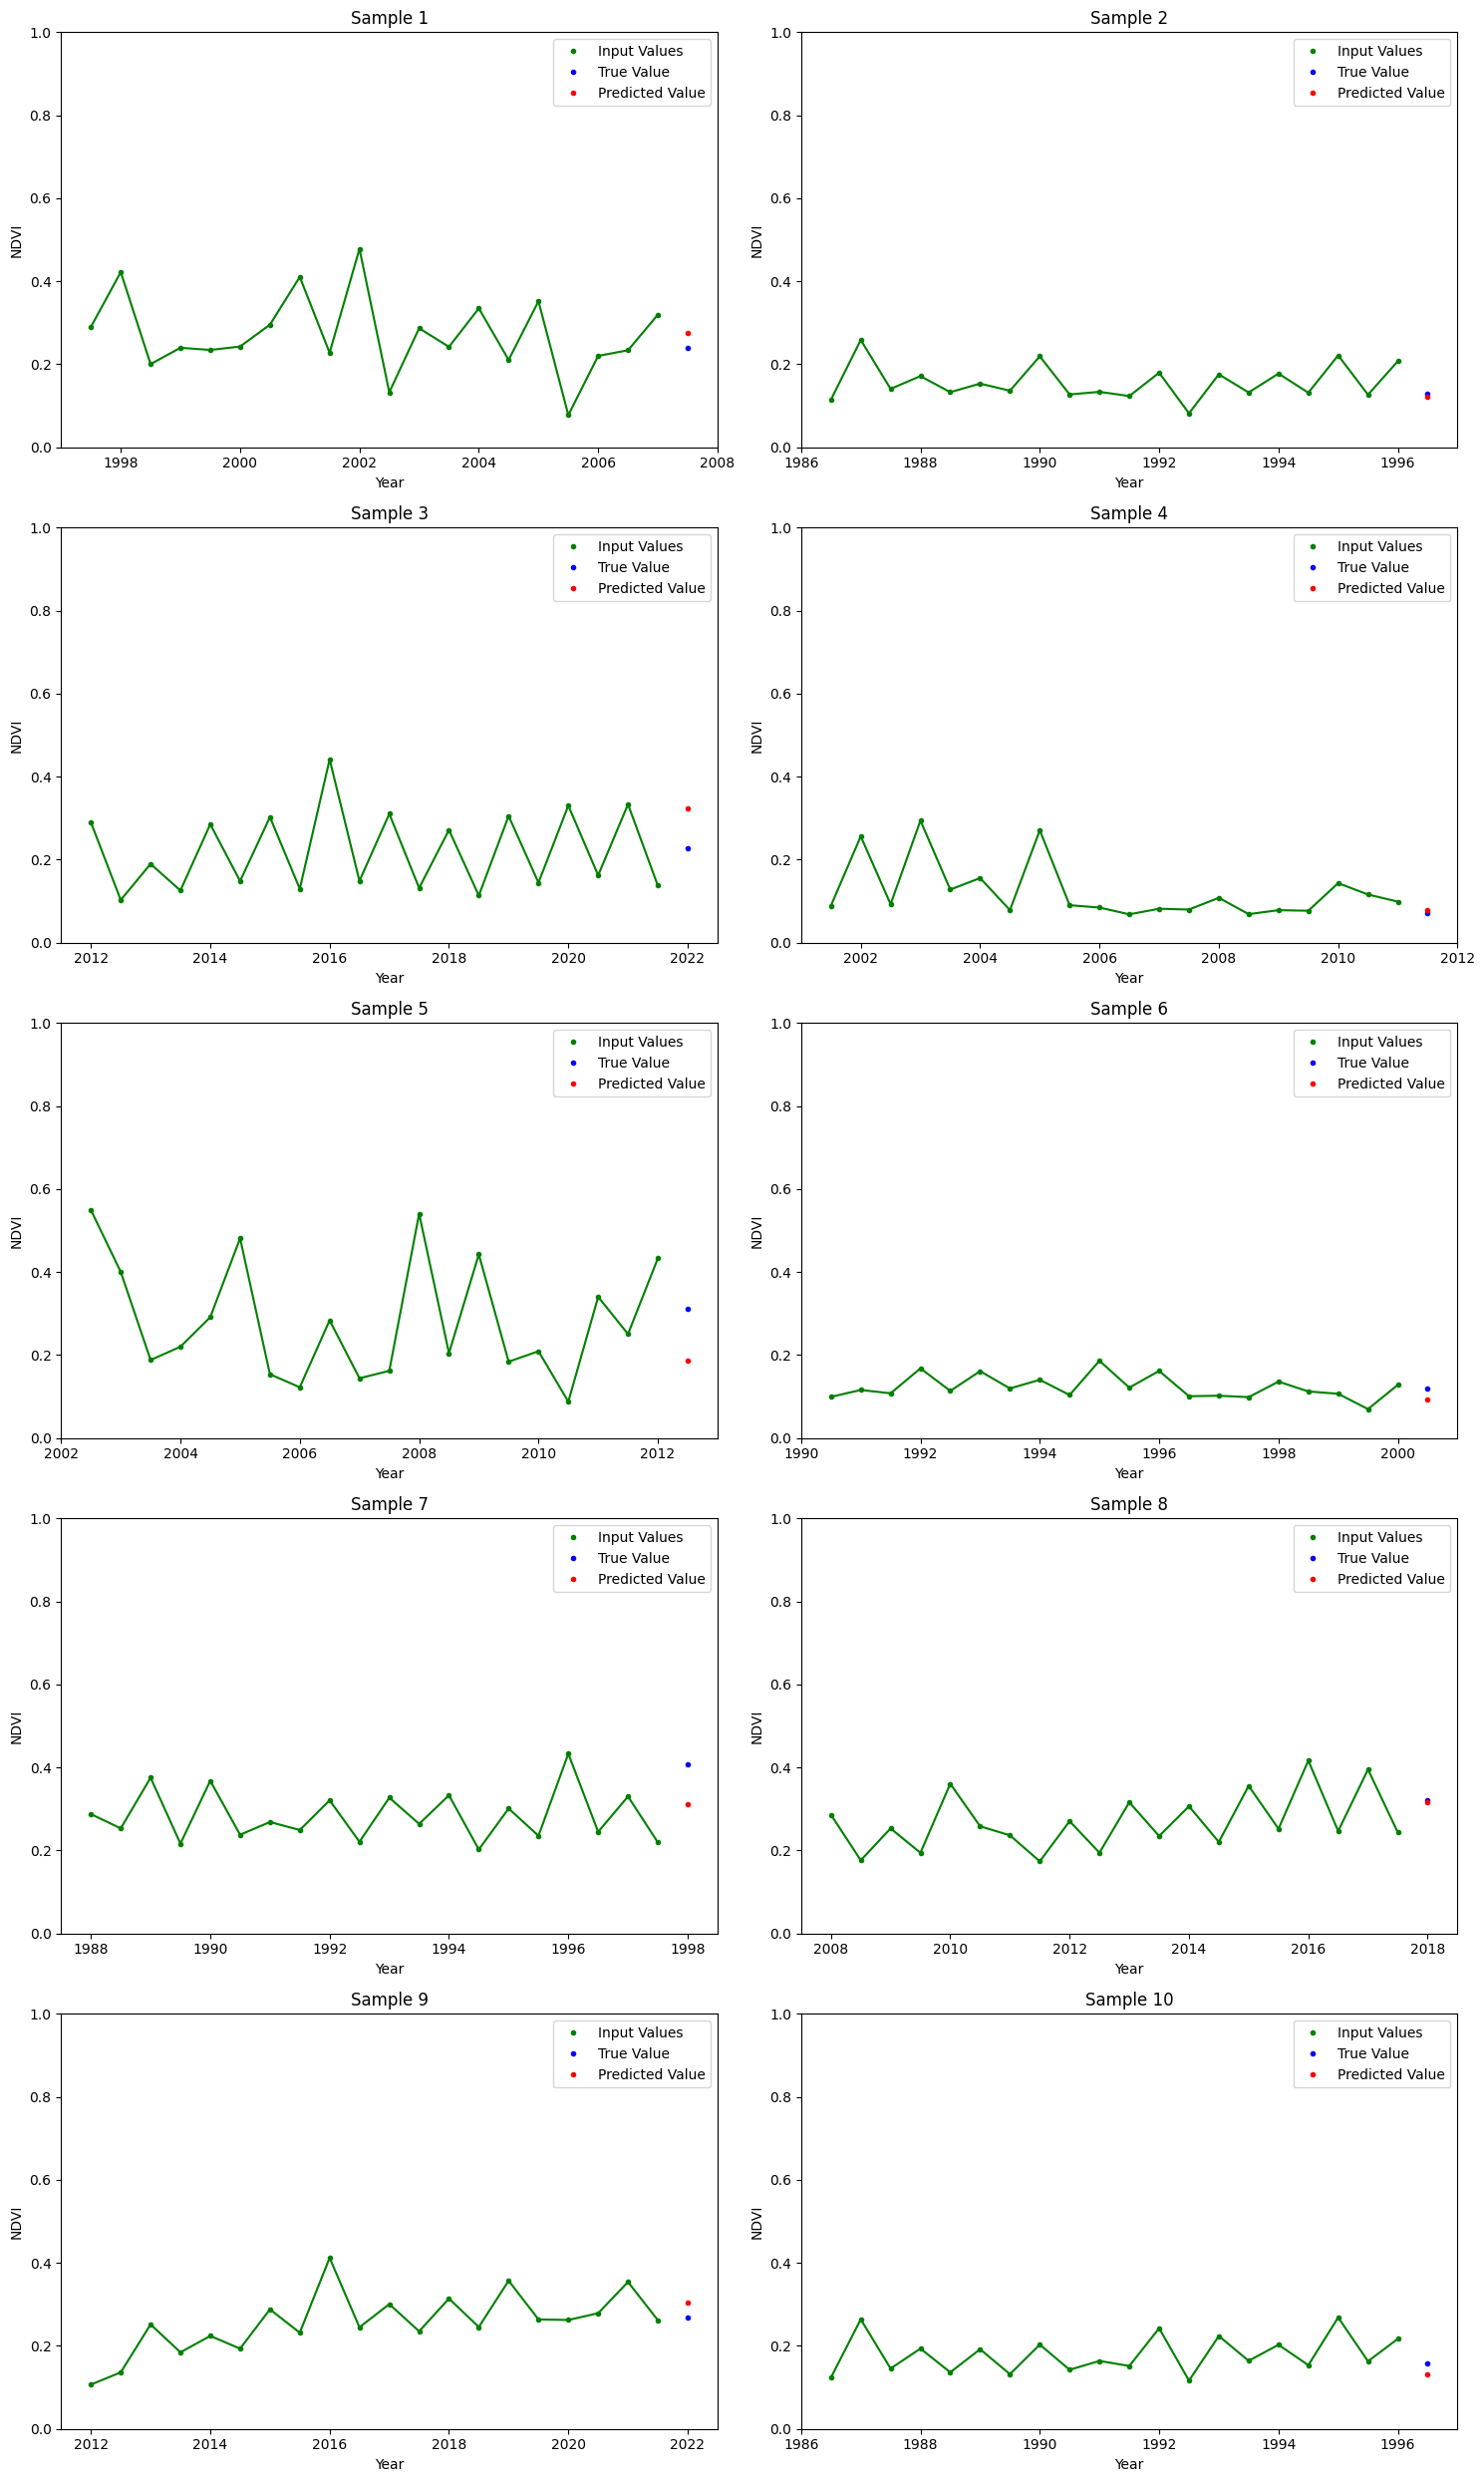

In [154]:
logging.info("Plotting predictions...")
plot_predictions(model, samples)

In [155]:
# load full data
from dataset import LandsatSpectralDataset

with rasterio.open("../data/Landsat_NDVI_time_series_1984_to_2024.tif") as src:
    ndvi_data: np.ndarray = src.read()
    band_names = src.descriptions
    logging.info(f"Original NDVI data shape: {ndvi_data.shape}")

# Extracting year information from band names
year_info = LandsatSpectralDataset.extract_year_info(band_names)
logging.info(f"Year information extracted: {year_info}")

ndvi_year_data = LandsatSpectralDataset.combine_ndvi_with_year(ndvi_data, year_info)
# restore original spatial dimensions
ndvi_year_data = ndvi_year_data.reshape(*ndvi_data.shape, 2)
logging.info(f"NDVI-Year data shape: {ndvi_year_data.shape}")

2024-12-14 22:48:47 - Original NDVI data shape: (82, 1798, 1245)
2024-12-14 22:48:47 - Year information extracted: {0: 1984, 1: 1984.5, 2: 1985, 3: 1985.5, 4: 1986, 5: 1986.5, 6: 1987, 7: 1987.5, 8: 1988, 9: 1988.5, 10: 1989, 11: 1989.5, 12: 1990, 13: 1990.5, 14: 1991, 15: 1991.5, 16: 1992, 17: 1992.5, 18: 1993, 19: 1993.5, 20: 1994, 21: 1994.5, 22: 1995, 23: 1995.5, 24: 1996, 25: 1996.5, 26: 1997, 27: 1997.5, 28: 1998, 29: 1998.5, 30: 1999, 31: 1999.5, 32: 2000, 33: 2000.5, 34: 2001, 35: 2001.5, 36: 2002, 37: 2002.5, 38: 2003, 39: 2003.5, 40: 2004, 41: 2004.5, 42: 2005, 43: 2005.5, 44: 2006, 45: 2006.5, 46: 2007, 47: 2007.5, 48: 2008, 49: 2008.5, 50: 2009, 51: 2009.5, 52: 2010, 53: 2010.5, 54: 2011, 55: 2011.5, 56: 2012, 57: 2012.5, 58: 2013, 59: 2013.5, 60: 2014, 61: 2014.5, 62: 2015, 63: 2015.5, 64: 2016, 65: 2016.5, 66: 2017, 67: 2017.5, 68: 2018, 69: 2018.5, 70: 2019, 71: 2019.5, 72: 2020, 73: 2020.5, 74: 2021, 75: 2021.5, 76: 2022, 77: 2022.5, 78: 2023, 79: 2023.5, 80: 2024, 81: 

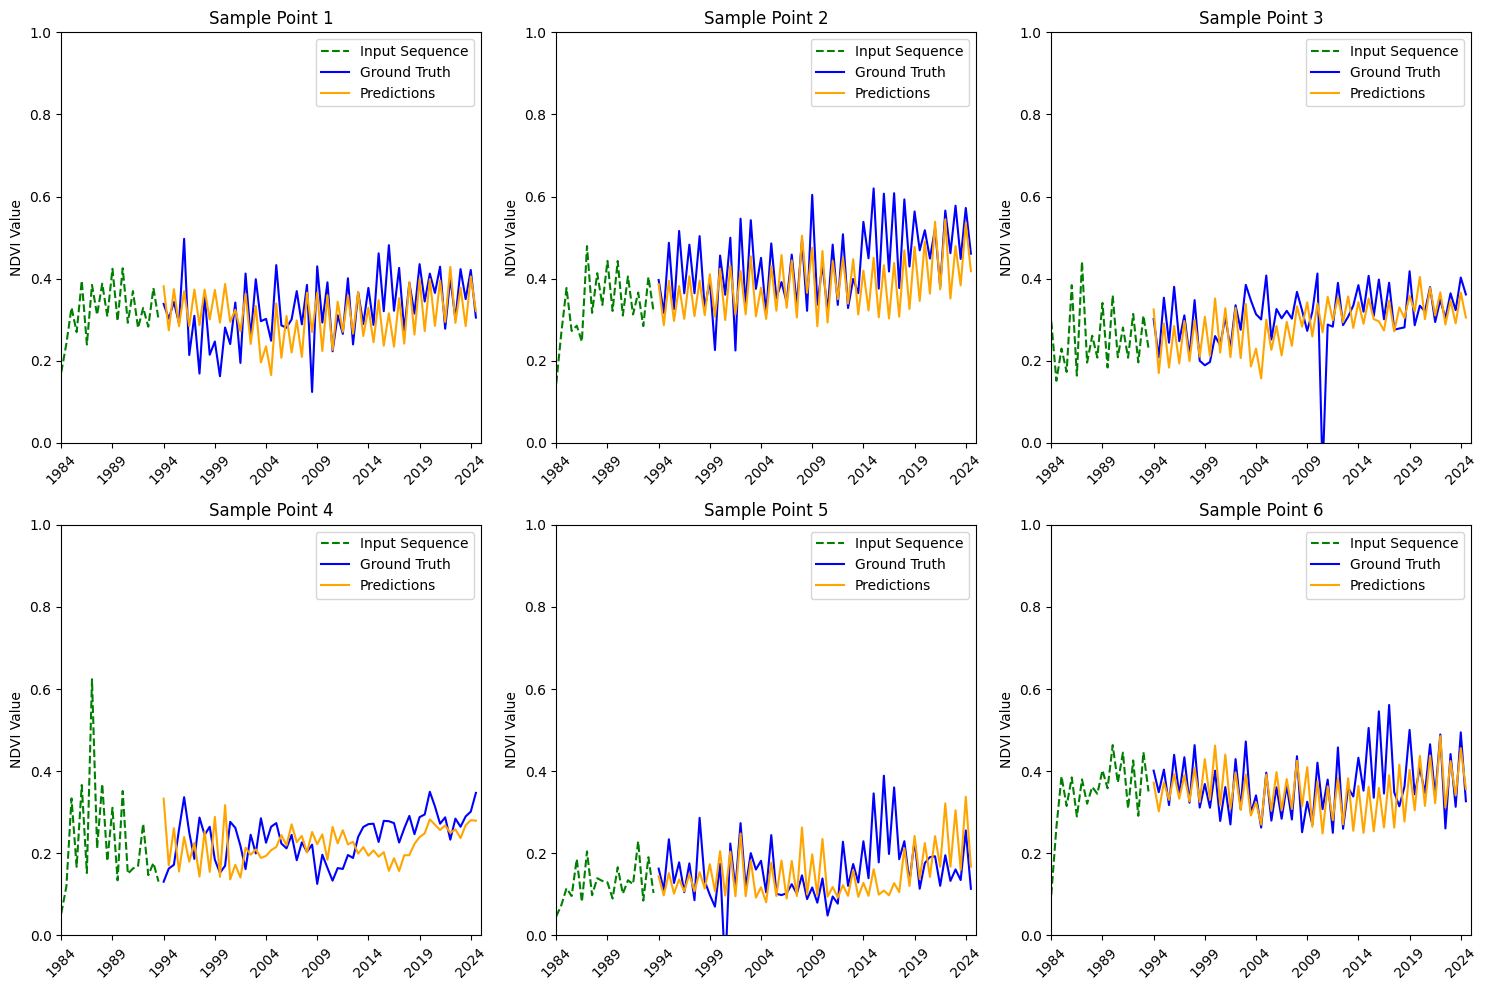

In [156]:
def sample_data(ndvi_year_data, num_samples):
    ndvi_year_data_reshaped = ndvi_year_data.reshape(ndvi_year_data.shape[0], -1, 2)
    sampled_indices = random.sample(range(ndvi_year_data_reshaped.shape[1]), num_samples)
    sampled_points = ndvi_year_data_reshaped[:, sampled_indices, :]
    return sampled_points

def generate_predictions(model, point, window_size, device):
    predictions = []
    ground_truth = []
    years = []

    for i in range(len(point) - window_size):
        input_seq = point[i:i + window_size]
        true_value = point[i + window_size, 0]  # NDVI value at the next time step
        year_value = point[i + window_size, 1]  # Year value at the next time step

        # Prepare input for the model
        x = torch.FloatTensor(input_seq[:, 0]).unsqueeze(0).unsqueeze(-1)  # NDVI values
        year_seq = torch.FloatTensor(input_seq[:, 1]).unsqueeze(0)  # Year values
        seasons = torch.where(year_seq % 1 == 0, 0, 1)

        # Move to device
        x = x.to(device)
        year_seq = year_seq.to(device)
        seasons = seasons.to(device)

        year_seq_int = year_seq.int()

        # Get model prediction
        with torch.no_grad():
            x = x.squeeze(-1)
            predicted_value = model(x, year_seq_int, seasons).cpu().numpy().flatten()[0]

        # Store predictions, ground truth, and years
        predictions.append(predicted_value)
        ground_truth.append(true_value)
        years.append(year_value)

    return predictions, ground_truth, years

def visualize_predictions(predictions_list, ground_truth_list, years_list, input_sequences_list, graphs_per_row):
    num_samples = len(predictions_list)
    num_rows = (num_samples + graphs_per_row - 1) // graphs_per_row  # Calculate the number of rows needed
    fig, axes = plt.subplots(num_rows, graphs_per_row, figsize=(15, 5 * num_rows), sharex=False)  # Allow independent X-axis values
    axes = axes.flatten()  # Flatten the axes array for easy indexing

    for idx, (predictions, ground_truth, years, input_seq) in enumerate(
        zip(predictions_list, ground_truth_list, years_list, input_sequences_list)
    ):
        axes[idx].plot(
            input_seq[:, 1], input_seq[:, 0], label='Input Sequence', color='green', linestyle='--'
        )  # Input Sequence visualization
        axes[idx].set_ylabel('NDVI Value')
        axes[idx].plot(years, ground_truth, label='Ground Truth', color='blue')
        axes[idx].plot(years, predictions, label='Predictions', color='orange')
        axes[idx].set_title(f'Sample Point {idx + 1}')
        axes[idx].legend()
        axes[idx].set_ylim(0, 1)  # Set y-axis scale to 0..1
        axes[idx].set_xlim(1984, 2025)  # Set the X-axis limits
        axes[idx].set_xticks(range(1984, 2026, 5))  # Set X-axis ticks every 5 years
        axes[idx].tick_params(axis='x', rotation=45)  # Rotate X-axis labels for better readability

    for ax in axes[num_samples:]:  # Hide any unused subplots
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Sample 6 points based on spatial dimension 1:2
num_samples = 6
sampled_points = sample_data(ndvi_year_data, num_samples)

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Store predictions, ground truth, and years for all sampled points
predictions_list = []
ground_truth_list = []
years_list = []
input_sequences_list = []

# Iterate over each sampled point
for idx, point in enumerate(sampled_points.transpose(1, 0, 2)):
    predictions, ground_truth, years = generate_predictions(model, point, window_size, device)
    input_sequences_list.append(point[:window_size])  # Store the input sequences (NDVI + years)
    predictions_list.append(predictions)
    ground_truth_list.append(ground_truth)
    years_list.append(years)

# Visualize all sampled points on the same image split into 5 graphs
graphs_per_row = 3  # Control how many graphs per row
visualize_predictions(predictions_list, ground_truth_list, years_list, input_sequences_list, graphs_per_row)

In [159]:
import torch
from sklearn.metrics import r2_score
from tqdm import tqdm
import numpy as np

def evaluate_model_on_sample(model, val_loader, device, sample_fraction):
    model.eval()
    criterion_mse = torch.nn.MSELoss(reduction="mean")
    criterion_mae = torch.nn.L1Loss(reduction="mean")

    total_samples = len(val_loader.dataset)
    sample_size = int(total_samples * sample_fraction)
    sampled_indices = torch.randperm(total_samples)[:sample_size]

    mse_losses = []
    mae_losses = []
    all_targets = []
    all_outputs = []

    with torch.no_grad():
        for idx in tqdm(sampled_indices, desc="Evaluating", unit="sample"):
            inputs, targets = val_loader.dataset[idx]
            inputs, targets = inputs.unsqueeze(0).to(device), targets.unsqueeze(0).to(device)  # Add batch dimension
            
            x, year_seq, seasons, targets = temporal_seq_data_shaping(inputs, targets, device)
            x = x.squeeze(-1)
            outputs = model(x, year_seq, seasons)
            y = targets[:, 0]
            if outputs.dim() > 1 and outputs.size(1) > 1:
                outputs = outputs[:, 0]
            mse_loss = criterion_mse(y, outputs).item()
            mae_loss = criterion_mae(y, outputs).item()
            
            # Ensure dimensions are compatible for concatenation
            all_targets.append(np.atleast_1d(y.cpu().numpy()))
            all_outputs.append(np.atleast_1d(outputs.cpu().numpy()))

            mse_losses.append(mse_loss)
            mae_losses.append(mae_loss)

    avg_mse_loss = sum(mse_losses) / len(mse_losses)
    avg_mae_loss = sum(mae_losses) / len(mae_losses)
    
    # Flatten the lists of arrays
    all_targets = np.concatenate(all_targets)
    all_outputs = np.concatenate(all_outputs)
    
    # Calculate R² score globally
    avg_r2_score = r2_score(all_targets, all_outputs)

    print(f"Evaluation on {sample_fraction*100}% of validation dataset:")
    print(f"  Mean Squared Error (MSE): {avg_mse_loss}")
    print(f"  Mean Absolute Error (MAE): {avg_mae_loss}")
    print(f"  R2 Score: {avg_r2_score}")

# Evaluate the model on 1% of the validation dataset
evaluate_model_on_sample(model, val_loader, device, sample_fraction=0.1)


Evaluating: 100%|██████████| 22385/22385 [01:12<00:00, 309.32sample/s]


Evaluation on 10.0% of validation dataset:
  Mean Squared Error (MSE): 0.007511074998217684
  Mean Absolute Error (MAE): 0.06131608651138414
  R2 Score: 0.5660783052444458
